In [4]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [5]:
cols_needed = [
    'case_status', 'decision_date', 'employer_name', 'employer_state',
    'wage_offer_from_9089', 'wage_offer_unit_of_pay_9089',
    'pw_soc_title', 'job_info_work_state'
]

df = pd.read_csv("us_perm_visas.csv", usecols=cols_needed, low_memory=False)
print(f"Loaded {len(df)} rows")
df.head()

Loaded 374362 rows


,case_status,decision_date,employer_name,employer_state,job_info_work_state,pw_soc_title,wage_offer_from_9089,wage_offer_unit_of_pay_9089
0,Certified,2012-02-01,NETSOFT USA INC.,NY,NY,"Computer Software Engineers, Applications",75629.0,yr
1,Denied,2011-12-21,PINNACLE ENVIRONEMNTAL CORP,NY,NY,Hazardous Materials Removal Workers,37024.0,yr
2,Certified,2011-12-01,"SCHNABEL ENGINEERING, INC.",VA,MD,Civil Engineers,47923.0,yr
3,Certified,2011-12-01,EBENEZER MISSION CHURCH,NY,NY,File Clerks,10.97,hr
4,Certified,2012-01-26,ALBANY INTERNATIONAL CORP.,NY,NY,Sales Engineers,100000.0,yr


In [6]:
df['decision_date'] = pd.to_datetime(df['decision_date'], errors='coerce')
df['decision_year'] = df['decision_date'].dt.year

# Keep only rows with a usable status and year
df_clean = df.dropna(subset=['case_status', 'decision_year'])
df_clean['decision_year'] = df_clean['decision_year'].astype(int)

print(df_clean['case_status'].value_counts())

case_status
Certified            181933
Certified-Expired    148586
Denied                25649
Withdrawn             18194
Name: count, dtype: int64


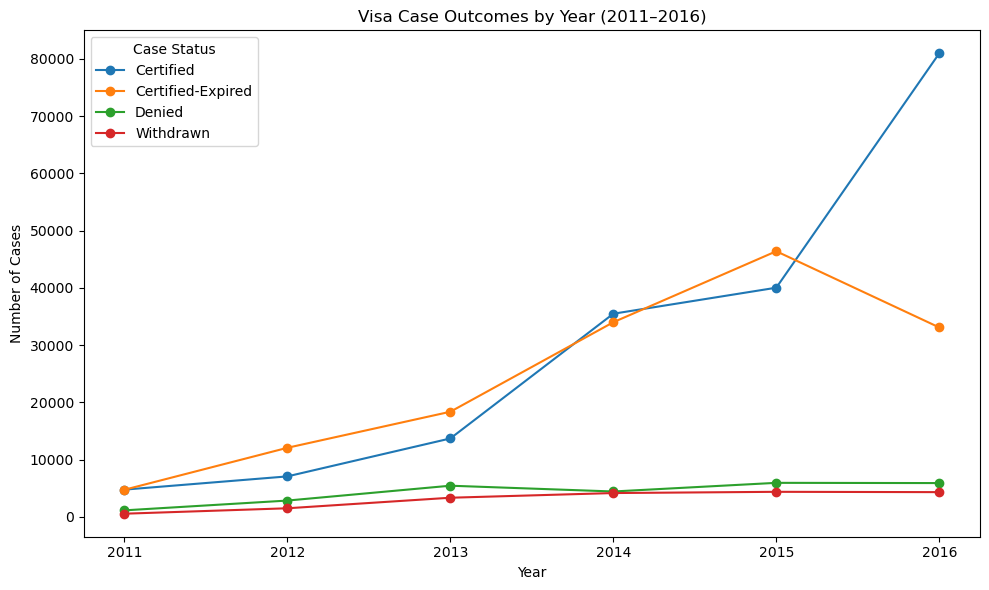

In [7]:
status_by_year = df_clean.groupby(['decision_year', 'case_status']).size().unstack(fill_value=0)

status_by_year.plot(kind='line', figsize=(10, 6), marker='o')
plt.title("Visa Case Outcomes by Year (2011–2016)")
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.legend(title="Case Status")
plt.tight_layout()
plt.show()

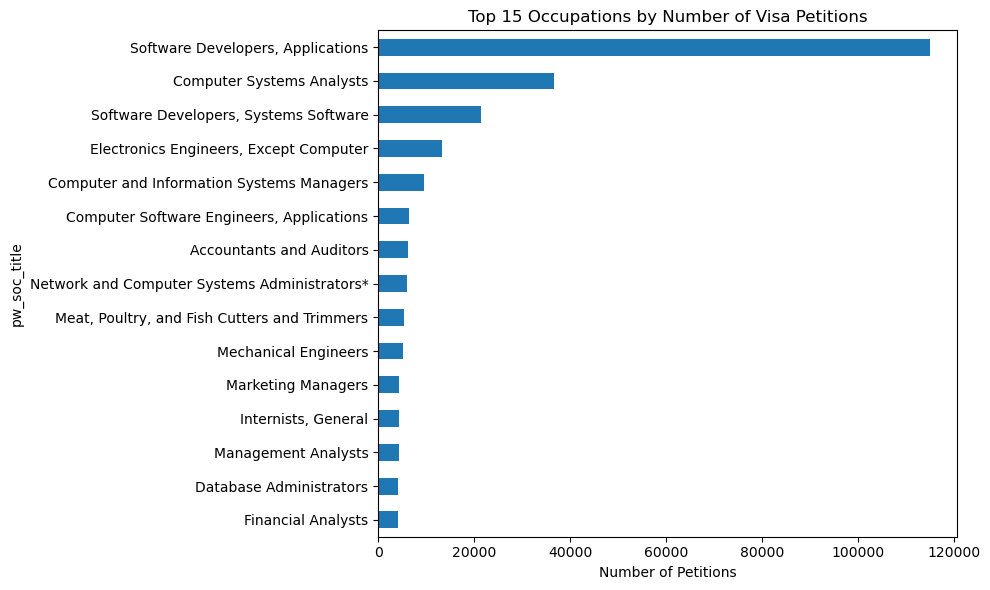

In [8]:
top_occupations = df_clean['pw_soc_title'].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_occupations.sort_values().plot(kind='barh')
plt.title("Top 15 Occupations by Number of Visa Petitions")
plt.xlabel("Number of Petitions")
plt.tight_layout()
plt.show()

In [9]:
print(df_clean['wage_offer_unit_of_pay_9089'].value_counts())


wage_offer_unit_of_pay_9089
Year         230591
yr            19733
Hour           7038
hr              781
Week            142
Month            81
wk               30
mth              21
Bi-Weekly        20
bi                9
Name: count, dtype: int64


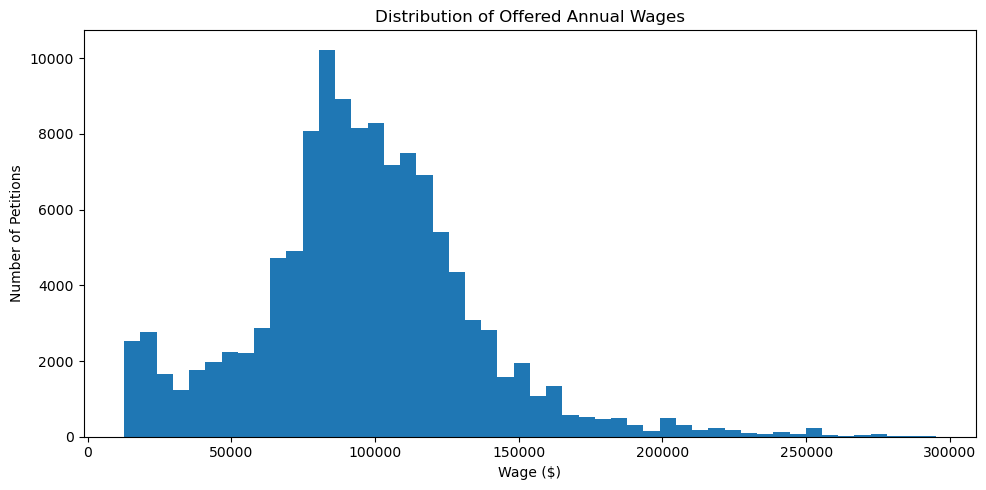

In [10]:
yearly_wage_df = df_clean[df_clean['wage_offer_unit_of_pay_9089'] == 'Year'].copy()
yearly_wage_df['wage_offer_from_9089'] = pd.to_numeric(
    yearly_wage_df['wage_offer_from_9089'], errors='coerce'
)

# filter out unrealistic outliers for a cleaner chart
wages = yearly_wage_df['wage_offer_from_9089']
wages = wages[(wages > 10000) & (wages < 300000)]

plt.figure(figsize=(10, 5))
plt.hist(wages, bins=50)
plt.title("Distribution of Offered Annual Wages")
plt.xlabel("Wage ($)")
plt.ylabel("Number of Petitions")
plt.tight_layout()
plt.show()